# Ejercicio 03 · Procesamiento de Lenguaje Natural

**Asignatura:** Ciencia de Datos II (INF-8239)  
**Dataset:** Inflation Research Abstracts Classification

## Objetivo

Construir y evaluar un flujo reproducible de clasificación de abstracts científicos relacionados con inflación, comparando un baseline y dos modelos de clasificación de texto mediante TF-IDF.

In [15]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = ROOT / "data" / "processed" / "dataset.csv"

RANDOM_STATE = 42

## 1. Carga del dataset

In [16]:
df = pd.read_csv(DATA_PATH)

print("Dimensiones:", df.shape)
display(df.head())

Dimensiones: (1138, 3)


,DOI,Abstract,Label
0,10.1155/2021/1071145,Forward-looking forecasting of the inflation r...,1
1,10.1007/s43546-022-00384-2,Our study examined the disaggregation of infla...,1
2,10.1002/for.2667,This paper develops a dynamic factor model tha...,0
3,10.1007/s42973-021-00091-x,"In this paper, I use a simple SIR Macro model ...",0
4,10.1007/s40258-012-0003-z,BackgroundGame theory is useful for identifyin...,0


## 2. Auditoría del corpus

In [17]:
print("Nulos:")
display(df[["Abstract", "Label"]].isna().sum())

print("Duplicados de texto:", df["Abstract"].duplicated().sum())

print("\nDistribución de clases:")
display(df["Label"].value_counts(normalize=True).sort_index())

Nulos:


Abstract    0
Label       0
dtype: int64

Duplicados de texto: 13

Distribución de clases:


Label
0    0.790861
1    0.209139
Name: proportion, dtype: float64

In [18]:
lengths = df["Abstract"].astype(str).str.len()

display(
    lengths.describe(
        percentiles=[0.50, 0.90, 0.99]
    )
)

count     1138.000000
mean      1145.284710
std        687.242316
min        113.000000
50%       1021.000000
90%       1709.900000
99%       3352.300000
max      14076.000000
Name: Abstract, dtype: float64

## 3. Preparación y prevención de fuga

In [19]:
df_model = (
    df.dropna(subset=["Abstract", "Label"])
      .drop_duplicates(subset=["Abstract"])
      .copy()
)

print("Registros originales:", len(df))
print("Registros después de eliminar duplicados:", len(df_model))

Registros originales: 1138
Registros después de eliminar duplicados: 1125


## 4. Partición entrenamiento/prueba

In [20]:
X = df_model["Abstract"]
y = df_model["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train:", len(X_train))
print("Test:", len(X_test))

print("\nDistribución en test:")
display(y_test.value_counts().sort_index())

Train: 843
Test: 282

Distribución en test:


Label
0    223
1     59
Name: count, dtype: int64

## 5. Modelos comparados

In [21]:
def make_pipeline(model):
    return Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=1,
                sublinear_tf=True,
            ),
        ),
        ("model", model),
    ])


models = {
    "DummyClassifier": make_pipeline(
        DummyClassifier(strategy="most_frequent")
    ),
    "Complement Naive Bayes": make_pipeline(
        ComplementNB()
    ),
    "Logistic Regression": make_pipeline(
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )
    ),
}

## 6. Evaluación comparativa

In [22]:
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    trained_models[name] = model

    results.append({
        "Modelo": name,
        "F1 macro": f1_score(y_test, pred, average="macro"),
        "Accuracy": accuracy_score(y_test, pred),
    })

results_df = pd.DataFrame(results)

display(results_df)

,Modelo,F1 macro,Accuracy
0,DummyClassifier,0.441584,0.790780
1,Complement Naive Bayes,0.459127,0.794326
2,Logistic Regression,0.837208,0.893617


In [23]:
best_model = trained_models["Logistic Regression"]
pred_logistic = best_model.predict(X_test)

print(
    classification_report(
        y_test,
        pred_logistic,
        digits=2,
    )
)

              precision    recall  f1-score   support

           0       0.93      0.94      0.93       223
           1       0.75      0.73      0.74        59

    accuracy                           0.89       282
   macro avg       0.84      0.83      0.84       282
weighted avg       0.89      0.89      0.89       282



## 7. Matriz de confusión

[[209  14]
 [ 16  43]]


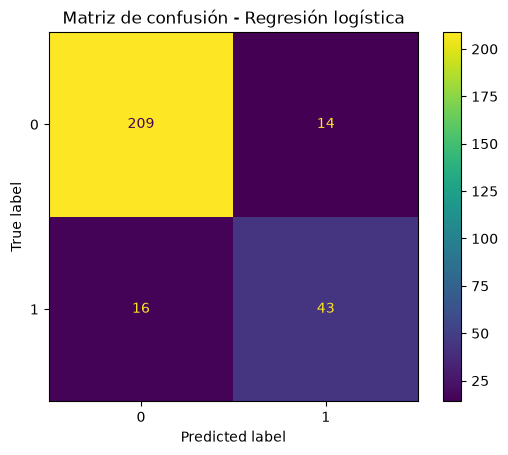

In [24]:
cm = confusion_matrix(y_test, pred_logistic)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.title("Matriz de confusión - Regresión logística")
plt.show()

## 8. Análisis de errores

In [25]:
errors = pd.DataFrame({
    "text": X_test,
    "real": y_test,
    "predicted": pred_logistic,
})

errors = errors[
    errors["real"] != errors["predicted"]
].copy()

print("Cantidad total de errores:", len(errors))

display(errors.head(20))

Cantidad total de errores: 30


,text,real,predicted
433,"Resumo Neste artigo, estimamos uma tendência p...",1,0
864,Professional analysts' judgments of the politi...,1,0
1031,Share of government expenditures in the GDPs a...,1,0
257,This paper aims to use the local level models ...,0,1
995,This paper aims at improving the prediction ac...,0,1
454,The aim of this research is to determine the d...,0,1
996,The Consumer Price Index (CPI) is an important...,0,1
980,The fluctuations of curly red chili price affe...,0,1
129,Abstract How do individuals ...,1,0
972,This article introduces a new class of functio...,0,1


In [26]:
categorized_path = ROOT / "reports" / "error_analysis_categorized.csv"

categorized = pd.read_csv(categorized_path)

display(categorized.head(20))

,text,real,predicted,category
0,"Resumo Neste artigo, estimamos uma tendência p...",1,0,ML poco explicito
1,Professional analysts' judgments of the politi...,1,0,etiqueta discutible
2,Share of government expenditures in the GDPs a...,1,0,ML explicito pero minoritario
3,This paper aims to use the local level models ...,0,1,prediccion estadistica confundida con ML
4,This paper aims at improving the prediction ac...,0,1,terminologia tecnica ambigua
5,The aim of this research is to determine the d...,0,1,prediccion estadistica confundida con ML
6,The Consumer Price Index (CPI) is an important...,0,1,prediccion estadistica confundida con ML
7,The fluctuations of curly red chili price affe...,0,1,terminologia tecnica ambigua
8,Abstract How do individuals ...,1,0,etiqueta discutible
9,This article introduces a new class of functio...,0,1,terminologia tecnica ambigua


In [27]:
summary_categories = (
    categorized.head(20)["category"]
    .value_counts()
    .rename_axis("Categoría")
    .reset_index(name="Cantidad")
)

display(summary_categories)

,Categoría,Cantidad
0,etiqueta discutible,6
1,terminologia tecnica ambigua,5
2,prediccion estadistica confundida con ML,4
3,ML explicito pero minoritario,2
4,ML poco explicito,1
5,ML diluido en texto largo,1
6,texto insuficiente,1


## 9. Conclusión

La regresión logística presentó el mejor desempeño entre los modelos evaluados, con un F1 macro de aproximadamente 0.837 y una accuracy de 0.89.

La clase 1 presentó mayor dificultad, con 16 falsos negativos y 14 falsos positivos. El análisis manual de 20 errores mostró que las categorías más frecuentes fueron las etiquetas discutibles, la terminología técnica ambigua y los casos de predicción estadística confundidos con machine learning.

Estos resultados muestran que TF-IDF junto con regresión logística constituye una línea base sólida para este corpus. Sin embargo, el modelo se basa principalmente en asociaciones léxicas y no comprende completamente la diferencia conceptual entre econometría, estadística predictiva y machine learning.

Por esta razón, el modelo debe interpretarse dentro del dominio documentado y no debe generalizarse automáticamente a otros idiomas, dominios o tipos de documentos sin una validación adicional.